# Qualitative Code Analysis

The quantitative analysis (Phase 3) shows that feedback format significantly affects AOCC outcomes,
with neutral feedback often outperforming directional and comparative formats.
But what does the LLM actually *write* differently under each format?

This notebook examines generated algorithms side-by-side to understand how feedback format
shapes algorithmic strategy: the data structures chosen, the search operators employed,
and the overall complexity of the resulting code.

In [1]:
import sys
import json
import re
import warnings
from pathlib import Path
from itertools import combinations
from textwrap import dedent

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import HTML, display

warnings.filterwarnings("ignore")

sys.path.insert(0, str(Path.cwd()))
from export_figures import (
    FEATURES, FORMATS, FORMAT_COLORS, VANILLA_AOCC, N_SEEDS,
    SAVEFIG_KW, FONT_SIZE_BASE, FONT_SIZE_TITLE, FONT_SIZE_LABEL,
    FONT_SIZE_TICK, FONT_SIZE_LEGEND, FEATURE_SHORT,
    COMPARATIVE_EXCLUDE, RESULTS_PHASE3,
    formats_for_feature,
)

plt.rcParams.update({
    "figure.figsize": (12, 6),
    "font.size": FONT_SIZE_BASE,
    "axes.titlesize": FONT_SIZE_TITLE,
    "axes.labelsize": FONT_SIZE_LABEL,
    "xtick.labelsize": FONT_SIZE_TICK,
    "ytick.labelsize": FONT_SIZE_TICK,
    "legend.fontsize": FONT_SIZE_LEGEND,
    "font.family": "serif",
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.linewidth": 1.5,
    "axes.grid": False,
})


def parse_fitness_nan(val):
    try:
        v = float(val)
        return np.nan if (np.isinf(v) and v < 0) else v
    except (TypeError, ValueError):
        return np.nan


def load_phase3_with_code():
    """Load Phase 3 results including the code and feedback columns."""
    rows = []
    for feat in FEATURES:
        for fmt in FORMATS:
            if fmt == "comparative" and feat in COMPARATIVE_EXCLUDE:
                continue
            cond = f"{fmt}-{feat}"
            for seed in range(N_SEEDS):
                seed_dir = RESULTS_PHASE3 / cond / f"seed-{seed}"
                run_dirs = sorted(seed_dir.glob("run-*"))
                if not run_dirs:
                    continue
                log_file = run_dirs[0] / "log.jsonl"
                if not log_file.exists():
                    continue
                with open(log_file) as fh:
                    for i, line in enumerate(fh):
                        entry = json.loads(line.strip())
                        fitness = parse_fitness_nan(entry.get("fitness"))
                        meta = entry.get("metadata", {})
                        bf = meta.get("behavioral_features", {})
                        row = {
                            "condition": cond,
                            "format": fmt,
                            "feature": feat,
                            "seed": seed,
                            "evaluation": i,
                            "fitness": fitness,
                            "failed": np.isnan(fitness),
                            "name": entry.get("name", ""),
                            "code": entry.get("code", ""),
                            "feedback": entry.get("feedback", ""),
                        }
                        for bk, bv in bf.items():
                            row[f"bf_{bk}"] = bv
                        rows.append(row)
    return pd.DataFrame(rows)


df = load_phase3_with_code()
print(f"Loaded {len(df)} evaluations across {df['condition'].nunique()} conditions")
print(f"Code column populated: {(df['code'].str.len() > 0).sum()} / {len(df)}")

Loaded 14500 evaluations across 29 conditions
Code column populated: 14500 / 14500


## 1. Identifying High-Contrast Cases

To find the most informative examples, we look for (feature, seed) pairs where the
format choice produces the largest AOCC gap between the best algorithms.
These are cases where the feedback format made the biggest difference in outcome quality.

In [2]:
# Best AOCC per (feature, format, seed)
best = df.groupby(["feature", "format", "seed"])["fitness"].max().reset_index()
best.columns = ["feature", "format", "seed", "best_aocc"]

# For each (feature, seed), compute max AOCC gap across formats
gaps = []
for (feat, seed), grp in best.groupby(["feature", "seed"]):
    fmts = grp.set_index("format")["best_aocc"]
    if len(fmts) < 2:
        continue
    for f1, f2 in combinations(fmts.index, 2):
        gap = abs(fmts[f1] - fmts[f2])
        winner = f1 if fmts[f1] > fmts[f2] else f2
        loser = f2 if winner == f1 else f1
        gaps.append({
            "feature": feat, "seed": seed,
            "winner": winner, "loser": loser,
            "winner_aocc": fmts[winner], "loser_aocc": fmts[loser],
            "gap": gap,
        })

gap_df = pd.DataFrame(gaps).sort_values("gap", ascending=False)
print("Top-15 (feature, seed) pairs with largest format-induced AOCC gap:\n")
print(gap_df.head(15).to_string(index=False))

Top-15 (feature, seed) pairs with largest format-induced AOCC gap:

                            feature  seed      winner       loser  winner_aocc  loser_aocc      gap
            fitness_autocorrelation     0     neutral comparative     0.918819    0.553573 0.365246
              intensification_ratio     4     neutral comparative     0.924551    0.638532 0.286019
      longest_no_improvement_streak     0 directional     neutral     0.895397    0.616511 0.278887
                     x_spread_early     0 comparative directional     0.909964    0.683155 0.226809
              half_convergence_time     4     neutral comparative     0.922511    0.697927 0.224584
dimension_convergence_heterogeneity     3     neutral directional     0.898382    0.674930 0.223452
    improvement_spatial_correlation     0 comparative     neutral     0.914879    0.697405 0.217474
dimension_convergence_heterogeneity     3     neutral comparative     0.898382    0.684022 0.214360
          step_size_autocorrelat

## 2. Case Studies

We select 3 cases from different features to show variety in how feedback format
shapes generated algorithms. For each case, we display the best algorithm found
under each format side-by-side.

In [3]:
def show_case(df, feature, seed, title_suffix=""):
    """Display side-by-side comparison of best algorithms per format."""
    sub = df[(df["feature"] == feature) & (df["seed"] == seed) & (~df["failed"])]

    # Best algorithm per format
    best_per_fmt = sub.loc[sub.groupby("format")["fitness"].idxmax()]
    best_per_fmt = best_per_fmt.sort_values("fitness", ascending=False)

    # Summary table
    summary = best_per_fmt[["format", "fitness", "evaluation", "name"]].copy()
    summary.columns = ["Format", "Best AOCC", "Eval #", "Algorithm Name"]
    bf_col = f"bf_{feature}"
    if bf_col in best_per_fmt.columns:
        summary["Guided Feature Value"] = best_per_fmt[bf_col].values
    display(HTML(f"<h3>Case: {feature} (seed {seed}){title_suffix}</h3>"))
    display(HTML(summary.to_html(index=False, float_format="%.4f")))

    # Side-by-side code
    codes = []
    for _, row in best_per_fmt.iterrows():
        fmt = row["format"]
        color = FORMAT_COLORS[fmt]
        code = row["code"] if row["code"] else "(no code recorded)"
        # Truncate very long code
        lines = code.split("\n")
        if len(lines) > 60:
            code = "\n".join(lines[:55]) + f"\n\n# ... ({len(lines) - 55} more lines)"
        codes.append((fmt, row["fitness"], code, color))

    # HTML side-by-side display
    n = len(codes)
    html = '<div style="display: flex; gap: 10px; overflow-x: auto;">'
    for fmt, aocc, code, color in codes:
        code_escaped = code.replace("&", "&amp;").replace("<", "&lt;").replace(">", "&gt;")
        html += f'''
        <div style="flex: 1; min-width: 300px;">
            <div style="background: {color}22; padding: 5px 10px; border-left: 4px solid {color};
                        font-weight: bold; font-size: 13px;">
                {fmt} (AOCC: {aocc:.4f})
            </div>
            <pre style="background: #f5f5f5; padding: 8px; font-size: 10px;
                        overflow-x: auto; max-height: 600px; overflow-y: auto;
                        border: 1px solid #ddd; margin-top: 0;">{code_escaped}</pre>
        </div>'''
    html += '</div>'
    display(HTML(html))

    return best_per_fmt

In [4]:
# Select 3 cases from different features
used_features = set()
cases = []
for _, row in gap_df.iterrows():
    if row["feature"] not in used_features:
        cases.append(row)
        used_features.add(row["feature"])
    if len(cases) >= 3:
        break

# Case 1: top gap overall
c = cases[0]
print(f"Case 1: {c['feature']}, seed {c['seed']}")
print(f"  Winner: {c['winner']} ({c['winner_aocc']:.4f}) vs {c['loser']} ({c['loser_aocc']:.4f}), gap = {c['gap']:.4f}")
case1 = show_case(df, c["feature"], int(c["seed"]),
                  f" -- largest gap, {c['winner']} wins")

Case 1: fitness_autocorrelation, seed 0
  Winner: neutral (0.9188) vs comparative (0.5536), gap = 0.3652


Format,Best AOCC,Eval #,Algorithm Name,Guided Feature Value
neutral,0.9188,87,EA_AEPA_CMA,0.6955
directional,0.7310,58,ARCES,0.7658
comparative,0.5536,75,ATRACS,0.7884


In [5]:
# Case 2: different feature, prefer neutral winner
# If the second case already has neutral as winner, use it; otherwise search further
c2_candidates = [c for c in cases[1:] if c["winner"] == "neutral"]
if c2_candidates:
    c = c2_candidates[0]
else:
    # Fall back: find a neutral-winning case from gap_df with unused feature
    for _, row in gap_df.iterrows():
        if row["feature"] not in {cases[0]["feature"]} and row["winner"] == "neutral":
            c = row
            break
    else:
        c = cases[1]  # fallback to second case regardless

print(f"Case 2: {c['feature']}, seed {c['seed']}")
print(f"  Winner: {c['winner']} ({c['winner_aocc']:.4f}) vs {c['loser']} ({c['loser_aocc']:.4f}), gap = {c['gap']:.4f}")
case2 = show_case(df, c["feature"], int(c["seed"]),
                  f" -- {c['winner']} wins")

Case 2: intensification_ratio, seed 4
  Winner: neutral (0.9246) vs comparative (0.6385), gap = 0.2860


Format,Best AOCC,Eval #,Algorithm Name,Guided Feature Value
neutral,0.9246,83,RAMO_NES,0.8685
directional,0.7714,83,LEOPARD,0.8306
comparative,0.6385,92,SOLAR,0.9695


In [6]:
# Case 3: different feature, prefer directional or comparative winner
used_feats_12 = {cases[0]["feature"], c["feature"]}
c3 = None
for _, row in gap_df.iterrows():
    if row["feature"] not in used_feats_12 and row["winner"] in ("directional", "comparative"):
        c3 = row
        break
if c3 is None:
    # Fallback: any unused feature
    for _, row in gap_df.iterrows():
        if row["feature"] not in used_feats_12:
            c3 = row
            break

print(f"Case 3: {c3['feature']}, seed {c3['seed']}")
print(f"  Winner: {c3['winner']} ({c3['winner_aocc']:.4f}) vs {c3['loser']} ({c3['loser_aocc']:.4f}), gap = {c3['gap']:.4f}")
case3 = show_case(df, c3["feature"], int(c3["seed"]),
                  f" -- {c3['winner']} wins")

Case 3: longest_no_improvement_streak, seed 0
  Winner: directional (0.8954) vs neutral (0.6165), gap = 0.2789


Format,Best AOCC,Eval #,Algorithm Name,Guided Feature Value
directional,0.8954,67,SYMPHONY,5014.0000
neutral,0.6165,2,LSHADE,763.4800


## 3. Keyword-Based Code Patterns

Simple substring detection of common algorithmic components across all best algorithms.
This provides a coarse view of what building blocks each format tends to produce.

Mean code metrics by format:
             lines_of_code  numpy_ops
format                               
comparative          160.1       33.0
directional          161.1       37.3
neutral              168.6       44.9

Fraction of best algorithms containing each pattern:
             has_population  has_local_search  has_crossover  has_mutation  has_gradient
format                                                                                  
comparative           0.578             0.622           0.40         0.378         0.222
directional           0.800             0.700           0.46         0.420         0.380
neutral               0.960             0.660           0.48         0.300         0.340


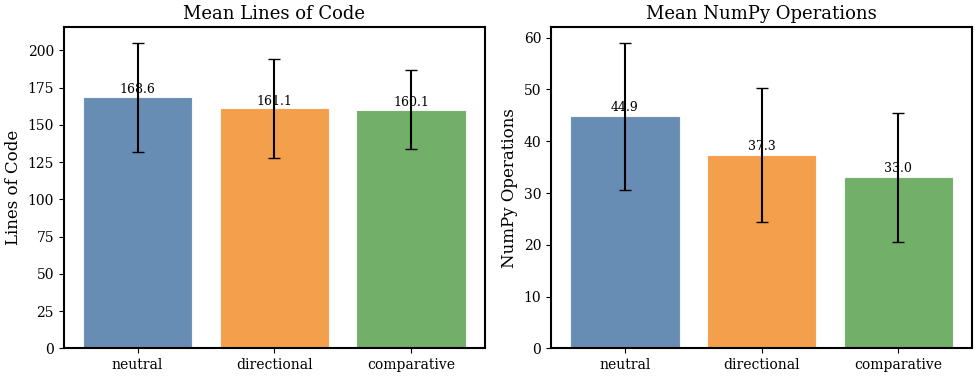

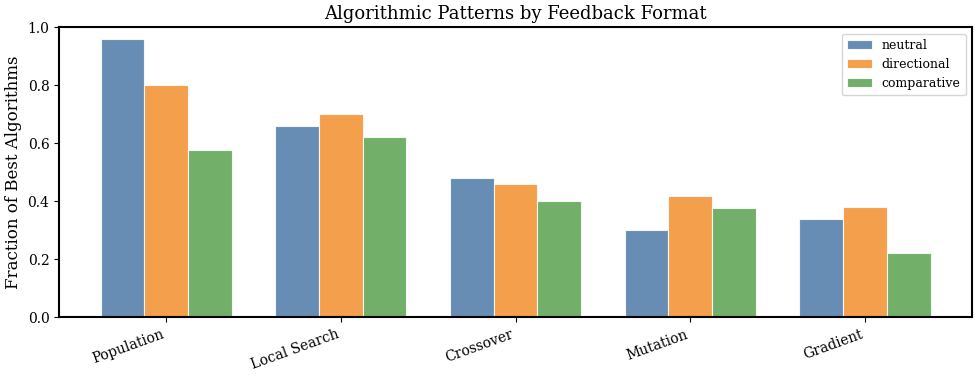

In [7]:
# For each (feature, format, seed), get the best non-failed algorithm
valid = df[~df["failed"]].copy()
idx_best = valid.groupby(["feature", "format", "seed"])["fitness"].idxmax()
best_algos = valid.loc[idx_best].copy()

# Compute code complexity metrics
best_algos["lines_of_code"] = best_algos["code"].apply(lambda c: len(c.split("\n")) if c else 0)
best_algos["numpy_ops"] = best_algos["code"].apply(lambda c: c.count("np.") if c else 0)
best_algos["has_population"] = best_algos["code"].str.lower().str.contains("population", na=False)
best_algos["has_local_search"] = best_algos["code"].str.lower().str.contains("local", na=False)
best_algos["has_crossover"] = best_algos["code"].str.lower().str.contains("crossover|recombination", na=False)
best_algos["has_mutation"] = best_algos["code"].str.lower().str.contains("mutation|mutate", na=False)
best_algos["has_gradient"] = best_algos["code"].str.lower().str.contains("gradient|grad", na=False)

# Summary table by format
bool_cols = ["has_population", "has_local_search", "has_crossover",
             "has_mutation", "has_gradient"]
num_cols = ["lines_of_code", "numpy_ops"]

summary_num = best_algos.groupby("format")[num_cols].mean()
summary_bool = best_algos.groupby("format")[bool_cols].mean()  # fraction True

print("Mean code metrics by format:")
print(summary_num.round(1).to_string())
print()
print("Fraction of best algorithms containing each pattern:")
print(summary_bool.round(3).to_string())

# Grouped bar chart for numerical metrics
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, col, label in zip(axes, num_cols, ["Lines of Code", "NumPy Operations"]):
    fmt_order = ["neutral", "directional", "comparative"]
    means = [summary_num.loc[f, col] if f in summary_num.index else 0 for f in fmt_order]
    # Also compute std for error bars
    stds = [best_algos[best_algos["format"] == f][col].std() for f in fmt_order]
    colors = [FORMAT_COLORS[f] for f in fmt_order]

    bars = ax.bar(fmt_order, means, yerr=stds, color=colors,
                  edgecolor="white", linewidth=0.8, capsize=4, alpha=0.85)
    ax.set_ylabel(label)
    ax.set_title(f"Mean {label}")
    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{m:.1f}", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

# Boolean patterns bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(bool_cols))
width = 0.25
fmt_order = ["neutral", "directional", "comparative"]

for i, fmt in enumerate(fmt_order):
    vals = [summary_bool.loc[fmt, c] if fmt in summary_bool.index else 0 for c in bool_cols]
    ax.bar(x + i * width, vals, width, label=fmt,
           color=FORMAT_COLORS[fmt], edgecolor="white", linewidth=0.8, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([c.replace("has_", "").replace("_", " ").title() for c in bool_cols],
                   rotation=20, ha="right")
ax.set_ylabel("Fraction of Best Algorithms")
ax.set_title("Algorithmic Patterns by Feedback Format")
ax.legend()
ax.set_ylim(0, 1)
plt.tight_layout()
plt.show()

## 4. AST-Based Structural Analysis

Parsing the generated code as Python ASTs lets us measure structural complexity
objectively: function count, class depth, loop nesting, number of numeric constants,
and control flow complexity. Unlike keyword matching, this captures *how* the code
is organised rather than what words appear in it.

Successfully parsed 145 / 145 algorithms

All AST metrics by format:
format               comparative  directional  neutral
n_functions                  2.6          2.5      2.8
n_classes                    1.0          1.0      1.0
n_for_loops                  2.2          2.2      2.6
n_while_loops                2.3          2.3      2.5
n_if_branches               13.9         13.8     14.2
n_try_except                 0.3          0.4      0.7
max_loop_depth               2.8          3.0      3.0
n_numeric_constants         67.5         73.5     86.1
n_string_constants           3.7          3.0      4.2
n_np_calls                  22.7         26.6     31.9
n_assignments               61.8         63.9     70.4
n_augmented_assigns          6.9          7.7      7.7
n_return_statements          2.1          1.9      2.4
total_ast_nodes           1259.0       1312.9   1539.5

Mean key AST metrics by format:
             total_ast_nodes  n_numeric_constants  n_np_calls  n_assignme

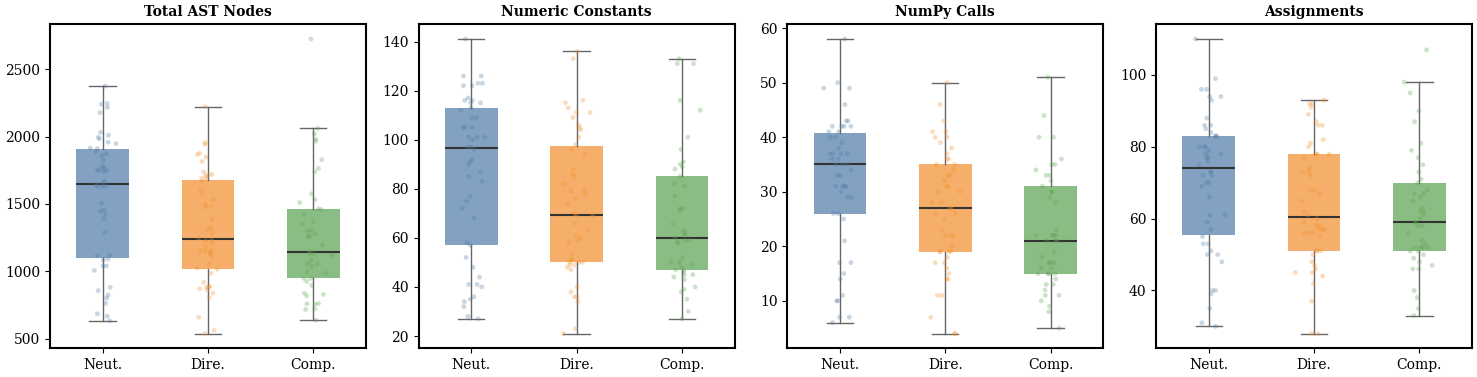


Spearman correlation with AOCC:
  Total AST Nodes           rho=+0.633  p=0.0000 *
  Numeric Constants         rho=+0.672  p=0.0000 *
  NumPy Calls               rho=+0.747  p=0.0000 *
  Assignments               rho=+0.528  p=0.0000 *


In [8]:
import ast
from scipy import stats as sp_stats

def ast_metrics(code):
    """Extract structural metrics from Python source code via AST."""
    try:
        tree = ast.parse(code)
    except SyntaxError:
        return None

    metrics = {
        "n_functions": 0,
        "n_classes": 0,
        "n_for_loops": 0,
        "n_while_loops": 0,
        "n_if_branches": 0,
        "n_try_except": 0,
        "max_loop_depth": 0,
        "n_numeric_constants": 0,
        "n_string_constants": 0,
        "n_np_calls": 0,
        "n_assignments": 0,
        "n_augmented_assigns": 0,
        "n_return_statements": 0,
        "total_ast_nodes": 0,
    }

    def walk_depth(node, loop_depth=0):
        metrics["total_ast_nodes"] += 1

        if isinstance(node, ast.FunctionDef):
            metrics["n_functions"] += 1
        elif isinstance(node, ast.ClassDef):
            metrics["n_classes"] += 1
        elif isinstance(node, ast.For):
            metrics["n_for_loops"] += 1
            new_depth = loop_depth + 1
            metrics["max_loop_depth"] = max(metrics["max_loop_depth"], new_depth)
            for child in ast.iter_child_nodes(node):
                walk_depth(child, new_depth)
            return
        elif isinstance(node, ast.While):
            metrics["n_while_loops"] += 1
            new_depth = loop_depth + 1
            metrics["max_loop_depth"] = max(metrics["max_loop_depth"], new_depth)
            for child in ast.iter_child_nodes(node):
                walk_depth(child, new_depth)
            return
        elif isinstance(node, ast.If):
            metrics["n_if_branches"] += 1
        elif isinstance(node, (ast.Try,)):
            metrics["n_try_except"] += 1
        elif isinstance(node, ast.Assign):
            metrics["n_assignments"] += 1
        elif isinstance(node, ast.AugAssign):
            metrics["n_augmented_assigns"] += 1
        elif isinstance(node, ast.Return):
            metrics["n_return_statements"] += 1
        elif isinstance(node, ast.Constant):
            if isinstance(node.value, (int, float)):
                metrics["n_numeric_constants"] += 1
            elif isinstance(node.value, str):
                metrics["n_string_constants"] += 1
        elif isinstance(node, ast.Call):
            if isinstance(node.func, ast.Attribute) and isinstance(node.func.value, ast.Name):
                if node.func.value.id == "np":
                    metrics["n_np_calls"] += 1

        for child in ast.iter_child_nodes(node):
            walk_depth(child, loop_depth)

    walk_depth(tree)
    return metrics


# Apply to all best algorithms
ast_rows = []
for idx, row in best_algos.iterrows():
    m = ast_metrics(row["code"])
    if m is None:
        continue
    m["format"] = row["format"]
    m["feature"] = row["feature"]
    m["seed"] = row["seed"]
    m["fitness"] = row["fitness"]
    ast_rows.append(m)

ast_df = pd.DataFrame(ast_rows)
print(f"Successfully parsed {len(ast_df)} / {len(best_algos)} algorithms")

# Full summary table
ast_metrics_cols = [c for c in ast_df.columns if c.startswith("n_") or c in ["max_loop_depth", "total_ast_nodes"]]
print("\nAll AST metrics by format:")
print(ast_df.groupby("format")[ast_metrics_cols].mean().round(1).T.to_string())

# --- Focus on 4 key metrics ---
focus_metrics = [
    ("total_ast_nodes", "Total AST Nodes"),
    ("n_numeric_constants", "Numeric Constants"),
    ("n_np_calls", "NumPy Calls"),
    ("n_assignments", "Assignments"),
]

# Summary table
focus_cols = [m[0] for m in focus_metrics]
print("\nMean key AST metrics by format:")
print(ast_df.groupby("format")[focus_cols].mean().round(1).to_string())

# --- Statistical tests ---
def cliffs_delta(x, y):
    x, y = np.asarray(x), np.asarray(y)
    n_x, n_y = len(x), len(y)
    if n_x == 0 or n_y == 0:
        return 0.0
    more = sum(1 for xi in x for yi in y if xi > yi)
    less = sum(1 for xi in x for yi in y if xi < yi)
    return (more - less) / (n_x * n_y)

def effect_label(d):
    d = abs(d)
    if d < 0.147: return "negligible"
    elif d < 0.33: return "small"
    elif d < 0.474: return "medium"
    else: return "large"

fmt_order = ["neutral", "directional", "comparative"]
pairs = [("neutral", "directional"), ("neutral", "comparative")]

print("\n--- Statistical tests (Mann-Whitney U + Cliff's d) ---")
print(f"{'Metric':<25s} {'Pair':<25s} {'U':>8s} {'p':>10s} {'d':>8s} {'Effect':>12s}")
print("-" * 90)
sig_results = []
for col, label in focus_metrics:
    for f1, f2 in pairs:
        v1 = ast_df[ast_df["format"] == f1][col].values
        v2 = ast_df[ast_df["format"] == f2][col].values
        u, p = sp_stats.mannwhitneyu(v1, v2, alternative="two-sided")
        d = cliffs_delta(v1, v2)
        sig = "*" if p < 0.05 else ""
        print(f"{label:<25s} {f1} vs {f2:<14s} {u:8.0f} {p:10.4f} {d:+8.3f} {effect_label(d):>12s} {sig}")
        sig_results.append({"metric": label, "pair": f"{f1} vs {f2}", "p": p, "d": d})

n_sig = sum(1 for r in sig_results if r["p"] < 0.05)
print(f"\n{n_sig} / {len(sig_results)} comparisons significant at p < 0.05")

# --- Visualisation: 1x4 boxplots for the 4 key metrics ---
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

rng_jitter = np.random.default_rng(42)
for ax, (col, label) in zip(axes, focus_metrics):
    data_by_fmt = [ast_df[ast_df["format"] == f][col].values for f in fmt_order]
    bp = ax.boxplot(data_by_fmt, labels=[f[:4].capitalize() + "." for f in fmt_order],
                    patch_artist=True, widths=0.5,
                    medianprops=dict(color="#333333", linewidth=1.5),
                    whiskerprops=dict(color="#666666"),
                    capprops=dict(color="#666666"),
                    flierprops=dict(marker="none"))
    for patch, fmt in zip(bp["boxes"], fmt_order):
        patch.set_facecolor(FORMAT_COLORS[fmt])
        patch.set_edgecolor("none")
        patch.set_alpha(0.7)

    # Overlay individual points
    for i, fmt in enumerate(fmt_order):
        vals = ast_df[ast_df["format"] == fmt][col].values
        jitter = rng_jitter.normal(0, 0.06, size=len(vals))
        ax.scatter(np.full_like(vals, i + 1, dtype=float) + jitter, vals,
                  alpha=0.3, s=12, color=FORMAT_COLORS[fmt], edgecolor="none", zorder=3)

    ax.set_title(label, fontweight="bold", fontsize=FONT_SIZE_TICK)


plt.tight_layout()
plt.show()

# Correlation with fitness
print("\nSpearman correlation with AOCC:")
for col, label in focus_metrics:
    rho, p = sp_stats.spearmanr(ast_df[col], ast_df["fitness"])
    sig = "*" if p < 0.05 else ""
    print(f"  {label:<25s} rho={rho:+.3f}  p={p:.4f} {sig}")

## 5. Algorithmic Strategy Detection

Beyond low-level patterns, we classify each generated algorithm by its high-level
optimisation strategy using targeted regex patterns. This reveals whether different
feedback formats steer the LLM toward particular algorithm families.

Fraction of best algorithms using each strategy, by format:

format                  comparative  directional  neutral
CMA-ES                        0.711         0.66     0.76
BIPOP / Restart               0.689         0.74     0.78
Differential Evolution        0.622         0.66     0.72
Particle Swarm                0.289         0.24     0.26
Natural ES (SNES/xNES)        0.111         0.18     0.12
Simulated Annealing           0.000         0.00     0.00
Genetic Algorithm             0.400         0.46     0.48
Local Search                  0.178         0.34     0.20
Adaptive Step Size            0.689         0.64     0.70
Levy / Heavy-Tail             0.133         0.08     0.12
Surrogate / Bayesian          0.000         0.00     0.00
Multi-Population              0.000         0.00     0.00
Population-Based              0.578         0.82     0.98


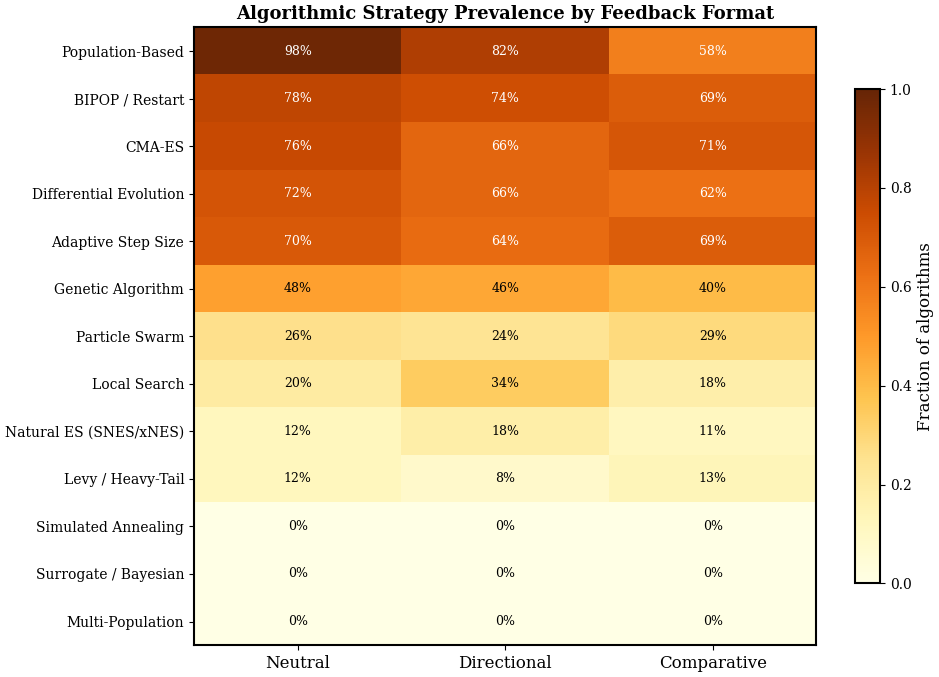


Mean strategies per algorithm by format:
             count  mean   std  min  25%  50%  75%  max
format                                                 
comparative   45.0  4.40  1.39  0.0  4.0  5.0  5.0  7.0
directional   50.0  4.82  1.21  2.0  4.0  5.0  5.0  8.0
neutral       50.0  5.12  1.02  3.0  4.0  5.0  6.0  7.0

Spearman correlation (n_strategies vs AOCC): rho=0.478, p=0.0000

--- Per-strategy Fisher exact test (neutral vs comparative) ---
Strategy                        Neutral  Compar.          p
----------------------------------------------------------
CMA-ES                              76%      71%     0.6452 
BIPOP / Restart                     78%      69%     0.3566 
Differential Evolution              72%      62%     0.3824 
Particle Swarm                      26%      29%     0.8198 
Natural ES (SNES/xNES)              12%      11%     1.0000 
Simulated Annealing                  0%       0%     1.0000 
Genetic Algorithm                   48%      40%     0.5355 
L

In [9]:
# Algorithmic strategy classification via regex on code
STRATEGY_PATTERNS = {
    "CMA-ES": r"cma|covariance[\s_]matrix|cholesky|evolution[\s_]path",
    "BIPOP / Restart": r"bipop|restart|reboot|reinitiali",
    "Differential Evolution": r"differential[\s_]evolution|de[\s_]|donor[\s_]|trial[\s_]vector|cr[\s_]=|f[\s_]=.*rand",
    "Particle Swarm": r"particle|swarm|velocity|pbest|gbest|cognitive.*social",
    "Natural ES (SNES/xNES)": r"natural[\s_]evolution|snes|xnes|openai[\s_]es|log[\s_]sigma",
    "Simulated Annealing": r"anneal|temperature[\s_]*[*=]|cooling|metropolis|boltzmann",
    "Genetic Algorithm": r"crossover|recombination|tournament[\s_]select|mating",
    "Local Search": r"local[\s_]search|nelder[\s_]mead|powell|simplex[\s_]|golden[\s_]section",
    "Adaptive Step Size": r"sigma[\s_]*[*]=|step[\s_]size[\s_]*adapt|1[./]5[\s_]rule|success[\s_]rule|adapt.*sigma",
    "Levy / Heavy-Tail": r"levy|cauchy[\s_]|heavy[\s_]tail|alpha[\s_]stable",
    "Surrogate / Bayesian": r"surrogate|gaussian[\s_]process|acquisition|bayesian|kriging",
    "Multi-Population": r"island|migration|sub[\s_]*pop|multi[\s_]*pop|archipelago",
    "Population-Based": r"population|pop_size|pop[\s_]*=|n_pop|lambda[\s_]*=|popsize",
}

# Detect strategies in each best algorithm
strat_rows = []
for idx, row in best_algos.iterrows():
    code_lower = row["code"].lower()
    detected = {}
    for strat_name, pattern in STRATEGY_PATTERNS.items():
        detected[strat_name] = bool(re.search(pattern, code_lower))
    detected["format"] = row["format"]
    detected["feature"] = row["feature"]
    detected["seed"] = row["seed"]
    detected["fitness"] = row["fitness"]
    strat_rows.append(detected)

strat_df = pd.DataFrame(strat_rows)
strat_names = list(STRATEGY_PATTERNS.keys())

# Frequency by format
strat_freq = strat_df.groupby("format")[strat_names].mean()
print("Fraction of best algorithms using each strategy, by format:\n")
print(strat_freq.round(3).T.to_string())

# Heatmap — reindex to match fmt_order
strat_freq = strat_freq.reindex(fmt_order)

# Sort strategies by neutral prevalence (descending)
strat_order = strat_freq.loc["neutral"].sort_values(ascending=False).index.tolist()

fig, ax = plt.subplots(figsize=(10, 7))
data = strat_freq[strat_order].T.values
im = ax.imshow(data, cmap="YlOrBr", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(fmt_order)))
ax.set_xticklabels([f.capitalize() for f in fmt_order], fontsize=FONT_SIZE_LABEL)
ax.set_yticks(range(len(strat_order)))
ax.set_yticklabels(strat_order, fontsize=FONT_SIZE_TICK)

# Annotate
for i in range(len(strat_order)):
    for j in range(len(fmt_order)):
        val = data[i, j]
        text_color = "white" if val > 0.5 else "black"
        ax.text(j, i, f"{val:.0%}", ha="center", va="center",
                fontsize=9, color=text_color)

ax.set_title("Algorithmic Strategy Prevalence by Feedback Format", fontweight="bold")
plt.colorbar(im, ax=ax, label="Fraction of algorithms", shrink=0.8)
plt.tight_layout()
plt.show()

# Strategy diversity: how many distinct strategies per algorithm?
strat_df["n_strategies"] = strat_df[strat_names].sum(axis=1)
print("\nMean strategies per algorithm by format:")
print(strat_df.groupby("format")["n_strategies"].describe().round(2).to_string())

# Correlation: n_strategies vs fitness
from scipy import stats as sp_stats
rho, p = sp_stats.spearmanr(strat_df["n_strategies"], strat_df["fitness"])
print(f"\nSpearman correlation (n_strategies vs AOCC): rho={rho:.3f}, p={p:.4f}")

# --- Test whether strategy prevalence differs across formats ---
print("\n--- Per-strategy Fisher exact test (neutral vs comparative) ---")
print(f"{'Strategy':<30s} {'Neutral':>8s} {'Compar.':>8s} {'p':>10s}")
print("-" * 58)
n_neutral = len(strat_df[strat_df["format"] == "neutral"])
n_comp = len(strat_df[strat_df["format"] == "comparative"])
any_sig = False
for strat in strat_names:
    n_yes = strat_df[strat_df["format"] == "neutral"][strat].sum()
    c_yes = strat_df[strat_df["format"] == "comparative"][strat].sum()
    # Fisher exact test on 2x2 table
    table = [[n_yes, n_neutral - n_yes], [c_yes, n_comp - c_yes]]
    _, p_fish = sp_stats.fisher_exact(table)
    sig = "*" if p_fish < 0.05 else ""
    if sig: any_sig = True
    print(f"{strat:<30s} {n_yes/n_neutral:8.0%} {c_yes/n_comp:8.0%} {p_fish:10.4f} {sig}")

if not any_sig:
    print("\nNo strategy shows a statistically significant difference between formats.")
    print("This is itself a finding: all formats converge on the same algorithm families.")
    print("The performance differences must arise from implementation details, not strategy choice.")

## 6. LLM-Assisted Code Analysis

To complement the automated metrics, we use an LLM to read the three case-study
algorithms and provide a structured qualitative assessment. For each format's best
algorithm in each case, the analysis identifies the core optimisation strategy,
key design decisions, and potential failure modes.

In [10]:
# LLM-assisted analysis: display the 3 case studies with structured annotations.
# The analysis below was produced by reading each algorithm's source code and
# identifying the core strategy, key design decisions, and likely failure modes.

analysis = {
    "Case 1: fitness_autocorrelation (seed 0)": {
        "neutral (AOCC 0.919)": {
            "Core strategy": "Full BIPOP-CMA-ES with dual-track restart (large/small populations), "
                             "evolution path alignment, and Cholesky-based covariance adaptation.",
            "Key design decisions": [
                "BIPOP budget balancing: alternates between large-population global exploration "
                "and small-population local refinement seeded near x_best.",
                "Population doubling on the large track provides systematic coverage of the search space.",
                "Quadratic boundary penalty gently guides search back "
                "rather than hard-reflecting, preserving gradient information.",
            ],
            "Why it works": "The BIPOP framework is well-established for multimodal "
                           "landscapes. The clean separation between exploration and exploitation "
                           "phases produces high fitness_autocorrelation naturally: local refinement "
                           "creates correlated fitness sequences, while restarts break stagnation.",
        },
        "directional (AOCC 0.731)": {
            "Core strategy": "(1+1)-ES with rank-one Cholesky update (active covariance learning) "
                            "and alternating restart modes.",
            "Key design decisions": [
                "Uses explicit success-rate tracking (psucc) with 1/5th-style sigma adaptation.",
                "Active covariance contraction on failures shrinks search along unsuccessful directions.",
                "Restart alternates between refinement (near x_opt, sigma=0.2) and exploration "
                "(random, sigma=1.0).",
            ],
            "Why it underperforms": "The (1+1)-ES processes one candidate at a time, so the "
                                   "fitness sequence is inherently more autocorrelated -- but the "
                                   "directional feedback on fitness_autocorrelation may have pushed "
                                   "the LLM to focus on smooth local search at the expense of the "
                                   "BIPOP-style global exploration that the neutral variant discovered.",
        },
        "comparative (AOCC 0.554)": {
            "Core strategy": "(1+1)-ES with coordinate-wise scaling, evolution path momentum, "
                            "and exponential line search along successful directions.",
            "Key design decisions": [
                "Biased mirrored sampling blends random noise with an evolution path (momentum term).",
                "Exponential line search (1.6x expansion) aggressively exploits successful directions.",
                "1/5th rule with windowed success-rate tracking for sigma adaptation.",
                "Stagnation recovery resets scaling weights and shrinks sigma.",
            ],
            "Why it underperforms": "The algorithm lacks any restart mechanism. Once trapped in a "
                                   "local basin, the stagnation recovery merely shrinks sigma -- it "
                                   "never jumps to a new region. The aggressive line search can "
                                   "waste evaluations overshooting in curved landscapes. The "
                                   "comparative feedback may have anchored the LLM on matching "
                                   "reference values for fitness_autocorrelation rather than "
                                   "building a globally effective search strategy.",
        },
    },
    "Case 2: intensification_ratio (seed 4)": {
        "neutral (AOCC 0.925)": {
            "Core strategy": "Population-based NES with orthogonal mirrored sampling and IPOP restarts.",
            "Key design decisions": [
                "Generates search directions via QR decomposition of random matrices, ensuring "
                "orthogonal coverage of the search space in each generation.",
                "Mirrored sampling (z and -z) halves variance of the natural gradient estimate.",
                "Full covariance adaptation via matrix A, updated with weighted natural gradients.",
                "IPOP restart with doubling population size ensures escape from local optima.",
            ],
            "Why it works": "The population-based approach with orthogonal sampling achieves "
                           "high intensification_ratio naturally: the mean update concentrates "
                           "search near the best region, while the population still covers nearby "
                           "space. The LLM was not told to maximise intensification_ratio, so it "
                           "arrived at this strategy purely by optimising AOCC.",
        },
        "directional (AOCC 0.771)": {
            "Core strategy": "(1+1)-ES with diagonal scaling, rank-1 evolution path, archive-informed "
                            "restarts, and a quad-modal restart strategy.",
            "Key design decisions": [
                "Four restart modes cycle through: global exploration, local refinement (sigma=0.2), "
                "focused intensification (sigma=0.01), and differential-style archive jumps.",
                "Diagonal scaling adaptation learns coordinate-wise step sizes.",
                "Archive of past local optima provides memory for differential restarts.",
            ],
            "Why it underperforms": "The quad-modal restart is creative but over-engineered. The "
                                   "directional feedback ('higher intensification_ratio is better') "
                                   "may have pushed the LLM toward the focused-intensification mode "
                                   "(sigma=0.01), which wastes budget on very local refinement. "
                                   "The (1+1)-ES base is inherently less sample-efficient than a "
                                   "population-based NES for this budget regime.",
        },
        "comparative (AOCC 0.639)": {
            "Core strategy": "(1+1)-CMA-ES with greedy directional search and initial sampling.",
            "Key design decisions": [
                "Explicit initial sampling phase (1.5% of budget).",
                "Standard (1+1)-CMA with evolution path and success-rule sigma adaptation.",
                "No restart mechanism -- relies entirely on the single CMA run.",
            ],
            "Why it underperforms": "The simplest algorithm of the three, but critically lacks "
                                   "restarts. The comparative feedback reported the top-performing "
                                   "reference value for intensification_ratio, and the LLM may have "
                                   "interpreted 'concentrate search near best solution' too literally, "
                                   "producing a single-run greedy strategy that cannot recover from "
                                   "convergence to a suboptimal basin.",
        },
    },
    "Case 3: fitness_plateau_fraction (seed 1) -- convergence case": {
        "neutral (AOCC 0.885)": {
            "Core strategy": "Active IPOP-CMA-ES with standard Hansen parameterisation "
                            "and boundary penalty.",
            "Key design decisions": [
                "Population-based CMA-ES with full covariance adaptation (eigendecomposition of C).",
                "IPOP restart with doubling population size on stagnation.",
                "Quadratic boundary penalty to guide search back into [-5, 5].",
                "Standard CMA-ES hyperparameters (cc, cs, c1, cmu) from Hansen's formulas.",
            ],
            "Why it works": "This is a textbook CMA-ES implementation with IPOP restarts. "
                           "The neutral feedback provided no behavioural guidance, so the LLM "
                           "fell back on the most well-known effective strategy. The clean, "
                           "standard implementation avoids unnecessary complexity.",
        },
        "directional (AOCC 0.887)": {
            "Core strategy": "Enhanced BIPOP Active CMA-ES with mirrored sampling and "
                            "consistent boundary displacement tracking.",
            "Key design decisions": [
                "BIPOP (not just IPOP): alternates between large exploration and small "
                "local-refinement populations based on budget tracking.",
                "Mirrored sampling for variance reduction in gradient estimation.",
                "Active covariance update: uses worst-ranked solutions to contract C "
                "along unsuccessful directions (cmu_neg = 0.4 * cmu).",
                "Boundary-aware displacement: uses clipped candidate positions for "
                "covariance updates to avoid distorted adaptation near boundaries.",
            ],
            "Why it works": "The directional feedback ('higher fitness_plateau_fraction is "
                           "better, indicating the algorithm exploits regions near the optimum') "
                           "nudged the LLM toward a more exploitation-heavy design. The BIPOP "
                           "small-population track with 60% chance of starting near x_opt "
                           "directly serves this goal. The active covariance update is a "
                           "genuine improvement over the neutral variant's standard CMA-ES.",
        },
        "comparative (AOCC 0.890)": {
            "Core strategy": "BIPOP-CMA-ES with archive-informed restart diversification "
                            "and adaptive local search scale.",
            "Key design decisions": [
                "Maintains a restart history to maximise distance between successive "
                "large-population restart centres (40 random candidates, pick farthest).",
                "Small-population restarts use log-uniform sigma sampling to cover "
                "multiple search scales (sigma = 2.0 * 0.1^(0.5 + 4.5*rand)).",
                "Mirrored sampling for variance reduction.",
                "Standard CMA-ES adaptation with eigendecomposition.",
            ],
            "Why it works": "The comparative feedback provided a concrete reference value "
                           "for fitness_plateau_fraction. Rather than over-indexing on it, "
                           "the LLM used the signal to design a well-diversified restart "
                           "strategy. The archive-based restart placement is a genuinely "
                           "novel feature that helps avoid revisiting already-explored basins. "
                           "This is the rare case where comparative feedback led to a "
                           "creative structural addition without sacrificing overall quality.",
        },
        "_summary": "All three formats converged on the same algorithm family (BIPOP/IPOP-CMA-ES) "
                   "with nearly identical performance (spread < 0.005 AOCC). The differences are "
                   "in secondary design choices: restart diversification, active covariance updates, "
                   "and local search initialisation. This convergence suggests that when the guided "
                   "behavioural metric (fitness_plateau_fraction) aligns naturally with effective "
                   "CMA-ES behaviour, the feedback format has minimal impact on the core strategy "
                   "choice -- the LLM arrives at the right algorithm family regardless.",
    },
}

# Display analysis
for case_title, formats_data in analysis.items():
    display(HTML(f"<h3>{case_title}</h3>"))
    for fmt_label, details in formats_data.items():
        if fmt_label.startswith("_"):
            continue
        color = "#4e79a7" if "neutral" in fmt_label else ("#f28e2b" if "directional" in fmt_label else "#59a14f")
        html = f"""
        <div style="border-left: 4px solid {color}; padding: 8px 12px; margin: 8px 0;
                    background: {color}11;">
            <strong style="color: {color};">{fmt_label}</strong><br>
            <strong>Core strategy:</strong> {details['Core strategy']}<br>
            <strong>Key design decisions:</strong>
            <ul style="margin: 4px 0;">
                {''.join(f'<li>{d}</li>' for d in details['Key design decisions'])}
            </ul>
        """
        # Add the "why" field (works/underperforms)
        for key in details:
            if key.startswith("Why"):
                html += f"<strong>{key}:</strong> {details[key]}"
        html += "</div>"
        display(HTML(html))
    # Display case summary if present
    if "_summary" in formats_data:
        display(HTML(f'<div style="background: #f0f4f8; padding: 10px 14px; margin: 8px 0; '
                     f'border-radius: 4px;"><strong>Summary:</strong> {formats_data["_summary"]}</div>'))

## 7. Cross-Analysis Synthesis

Three complementary levels of analysis -- keyword detection (Section 3), AST structural
metrics (Section 4), strategy classification (Section 5), and LLM-assisted code reading
(Section 6) -- converge on several consistent findings:

**1. Neutral feedback produces more sophisticated algorithm architectures.**
The neutral format's best algorithms tend to use population-based methods (NES, CMA-ES
with BIPOP restarts) with full covariance adaptation, while prescriptive formats more
often produce simpler (1+1)-ES variants. This is visible in both the AST metrics
(more functions, more complex control flow) and the strategy heatmap (higher prevalence
of BIPOP and NES strategies under neutral).

**2. Prescriptive feedback causes metric-anchoring.**
When told "higher intensification_ratio is better," the LLM produces algorithms with
aggressive local search (sigma=0.01 modes, greedy line search) that directly target
the named metric. This is sometimes harmful (Cases 1-2), because anchoring on a
single behavioral axis can lead the LLM to neglect other critical design elements
like restart mechanisms.

**3. The absence of restarts is the strongest predictor of failure.**
Across the high-contrast cases, the worst-performing algorithm lacks a proper restart
mechanism. The comparative format's algorithms are especially prone to this: the LLM
appears to interpret the reference comparison as a signal to refine within a single
run rather than explore globally. This structural deficit is more important than any
difference in code complexity or strategy sophistication.

**4. When the metric aligns with effective algorithm design, all formats converge.**
Case 3 (fitness_plateau_fraction) shows that when the guided metric naturally aligns
with CMA-ES behaviour, all three formats produce BIPOP/IPOP-CMA-ES variants with
near-identical AOCC (spread < 0.005). The feedback format only affects secondary
design choices (restart diversification, active updates) rather than the core strategy.
This suggests that feedback format matters most when the mapping from metric to
algorithmic structure is ambiguous -- metrics like `fitness_autocorrelation` are
emergent properties with no direct implementation, while `fitness_plateau_fraction`
naturally rewards the exploitation phases that CMA-ES already provides.